# Multi-Touch Marketing Attribution Analysis Using GA4 Event Data

This project analyzes customer journeys using event-level data from the Google Analytics 4 (GA4) public dataset.

The goal is to understand how different marketing channels contribute to conversions by reconstructing user journeys and applying multiple attribution models.

Key questions explored in this analysis:

• Which channels drive customer acquisition?  
• Which channels close conversions?  
• Which channels assist conversions along the customer journey?  
• How do different attribution models change the perceived value of marketing channels?

The analysis uses Python to reconstruct customer journeys and evaluate attribution using first-click, last-click, and linear attribution models.

## Business Problem

Marketing teams invest across multiple channels such as organic search, referrals, paid search, and direct traffic.

However, customers typically interact with several channels before completing a purchase.

Traditional last-click attribution assigns full credit to the final interaction before conversion, which can underestimate the role of earlier touchpoints that influence discovery and consideration.

This project evaluates marketing channel contributions using multiple attribution models to better understand how users move through the purchase funnel.

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("ga4_marketing_data.csv")

df.head()

,user_pseudo_id,event_timestamp,event_name,source,medium,campaign
0,1.066406e+06,1605802271820796,session_start,(data deleted),(data deleted),(data deleted)
1,1.144538e+06,1605767542226093,session_start,(data deleted),(data deleted),(data deleted)
2,1.296667e+06,1605779446617183,session_start,(data deleted),(data deleted),(data deleted)
3,1.308975e+06,1605772984278555,session_start,(data deleted),(data deleted),(data deleted)
4,1.428977e+06,1605829325282508,session_start,(data deleted),(data deleted),(data deleted)


## Dataset Overview

The dataset used in this analysis is the Google Analytics 4 public ecommerce dataset available through BigQuery.

The dataset contains anonymized event-level interaction data including:

• user identifiers  
• event timestamps  
• traffic sources  
• marketing campaign metadata  
• purchase events

Each event represents an interaction a user had with the website, such as starting a session, viewing pages, or completing a purchase.

For attribution analysis, the key events used are:

• session_start → marketing touchpoints  
• purchase → conversion event

## Data Preparation

The dataset contains raw GA4 event-level data. To prepare it for attribution analysis:

• Only relevant events were retained (`session_start`, `purchase`)  
• Missing and anonymized values were standardized  
• Raw source/medium values were grouped into marketing channels

In [4]:
# Filter relevant events
df_attr = df[df["event_name"].isin(["session_start", "purchase"])].copy()

# Clean channel function
def clean_channel(source, medium):

    source = str(source).lower()
    medium = str(medium).lower()

    if source == "(direct)" and medium == "(none)":
        return "Direct"

    if "cpc" in medium or "ppc" in medium:
        return "Paid Search"

    if "organic" in medium:
        return "Organic Search"

    if "referral" in medium:
        return "Referral"

    if "data deleted" in source or "unknown" in source or "<other>" in source:
        return "Unknown"

    return "Other"


df_attr["channel_group"] = df_attr.apply(
    lambda x: clean_channel(x["source"], x["medium"]), axis=1
)

df_attr["channel_group"] = df_attr["channel_group"].fillna("Unknown")

## Customer Journey Construction

Customer journeys are built by ordering user interactions chronologically and tracking the sequence of marketing touchpoints.

In [5]:
df_attr = df_attr.sort_values(["user_pseudo_id", "event_timestamp"])

df_attr["touchpoint"] = df_attr["channel_group"]
df_attr.loc[df_attr["event_name"] == "purchase", "touchpoint"] = "Conversion"

journeys = df_attr.groupby("user_pseudo_id")["touchpoint"].apply(list)

# Keep only converting users
conversion_journeys = journeys[journeys.apply(lambda x: "Conversion" in x)]

# Remove conversion marker
conversion_paths = conversion_journeys.apply(
    lambda x: [step for step in x if step != "Conversion"]
)

conversion_paths.head()

,touchpoint
user_pseudo_id,
1.052482e+06,[Referral]
1.146540e+06,[Direct]
1.158637e+06,[Direct]
1.160488e+06,[Direct]
1.193143e+06,[Organic Search]


## First Click Attribution

Assigns full credit to the first channel that brought the user.

In [6]:
first_click = conversion_paths.apply(lambda x: x[0] if len(x) > 0 else "Unknown")
first_click_counts = first_click.value_counts()

first_click_counts

,count
touchpoint,
Organic Search,133
Unknown,114
Direct,100
Referral,93
Paid Search,17


## Last Click Attribution

Assigns full credit to the final channel before conversion.

In [7]:
last_click = conversion_paths.apply(lambda x: x[-1] if len(x) > 0 else "Unknown")
last_click_counts = last_click.value_counts()

last_click_counts

,count
touchpoint,
Unknown,130
Organic Search,119
Referral,99
Direct,95
Paid Search,14


### Interpretation

The comparison between first-click and last-click attribution reveals how different channels contribute across the customer journey.

Organic Search shows a stronger contribution under first-click attribution than last-click, suggesting it plays a key role in **customer acquisition and discovery**.

In contrast, Direct traffic maintains a relatively strong presence in last-click attribution. This indicates that many users return directly to the website when they are ready to complete a purchase.

This pattern suggests a typical journey:

Organic Search → Referral/Other → Direct → Conversion

Relying only on last-click attribution would overestimate the importance of Direct traffic while underestimating the role of acquisition channels.

## Linear Attribution

Distributes credit equally across all touchpoints.

In [8]:
linear_credit = defaultdict(float)

for path in conversion_paths:
    if len(path) > 0:
        credit = 1 / len(path)
        for channel in path:
            linear_credit[channel] += credit

linear_attribution = pd.Series(linear_credit).sort_values(ascending=False)

linear_attribution

,0
Organic Search,125.050000
Unknown,112.145238
Referral,97.261905
Direct,96.792857
Paid Search,15.750000


### Interpretation

Linear attribution provides a more balanced view of channel contribution by distributing credit across all touchpoints.

Compared to first- and last-click models, the differences between channels are less extreme, highlighting that conversions are typically the result of multiple interactions rather than a single touchpoint.

Organic Search and Referral continue to show strong contributions, reinforcing their importance in early and mid-funnel engagement.

This suggests that marketing performance should be evaluated using multi-touch approaches rather than relying on a single attribution model.

## Attribution Model Comparison

In [9]:
comparison = pd.DataFrame({
    "First Click": first_click_counts,
    "Last Click": last_click_counts,
    "Linear": linear_attribution
}).fillna(0)

comparison

,First Click,Last Click,Linear
Direct,100,95,96.792857
Organic Search,133,119,125.050000
Paid Search,17,14,15.750000
Referral,93,99,97.261905
Unknown,114,130,112.145238


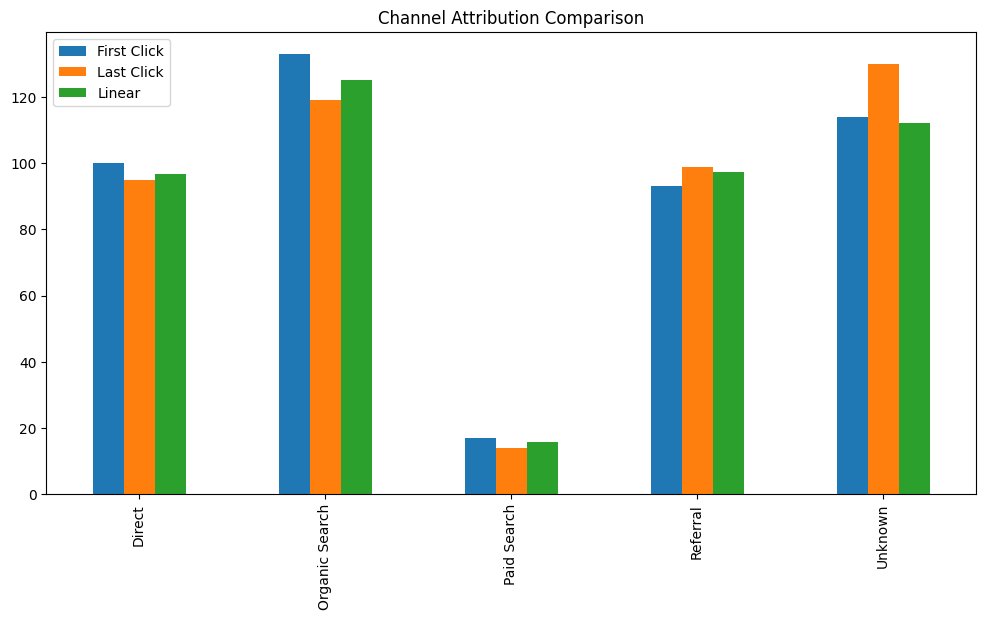

In [10]:
comparison.plot(kind="bar", figsize=(12,6))
plt.title("Channel Attribution Comparison")
plt.show()

### Interpretation

Comparing attribution models reveals how marketing performance evaluation can change significantly depending on the methodology used.

First-click attribution emphasizes acquisition channels such as Organic Search, while last-click attribution shifts credit toward Direct traffic.

Linear attribution provides a more balanced perspective, showing that multiple channels contribute throughout the customer journey.

This highlights a key limitation of last-click attribution: it tends to over-credit final touchpoints and under-represent channels that drive discovery and engagement.

For marketing decision-making, relying on a single attribution model may lead to suboptimal budget allocation. A multi-touch approach provides a more accurate representation of channel impact.

## Assisted Conversion Analysis

In [11]:
assist_counts = defaultdict(int)

for path in conversion_paths:
    if len(path) > 1:
        for channel in path[:-1]:
            assist_counts[channel] += 1

assist_series = pd.Series(assist_counts).sort_values(ascending=False)

assist_series

,0
Referral,66
Unknown,64
Organic Search,62
Direct,48
Paid Search,9


In [12]:
assist_counts = defaultdict(int)

for path in conversion_paths:
    if len(path) > 1:
        for channel in path[:-1]:
            assist_counts[channel] += 1

assist_series = pd.Series(assist_counts).sort_values(ascending=False)

assist_series

,0
Referral,66
Unknown,64
Organic Search,62
Direct,48
Paid Search,9


### Interpretation

Assisted conversion analysis highlights channels that contribute to the customer journey but do not receive final attribution credit.

Referral and Organic Search show the highest number of assisted conversions, indicating that they play a significant role in **guiding users through the consideration phase**.

These channels frequently appear earlier in the journey and help move users closer to conversion.

Direct traffic, on the other hand, shows fewer assisted interactions, reinforcing the idea that it primarily represents **returning users completing their purchase**.

This analysis demonstrates that focusing only on last-click attribution would undervalue the contribution of channels that support earlier stages of the funnel.

## Channel Performance Analysis

In [13]:
traffic_counts = df_attr[df_attr["event_name"]=="session_start"]["channel_group"].value_counts()

channel_performance = pd.DataFrame({
    "Sessions": traffic_counts,
    "Last Click Conversions": last_click_counts
}).fillna(0)

channel_performance["Conversion Rate"] = (
    channel_performance["Last Click Conversions"] /
    channel_performance["Sessions"]
)

channel_performance

,Sessions,Last Click Conversions,Conversion Rate
Direct,11622,95,0.008174
Organic Search,16959,119,0.007017
Paid Search,2173,14,0.006443
Referral,8459,99,0.011704
Unknown,10137,130,0.012824


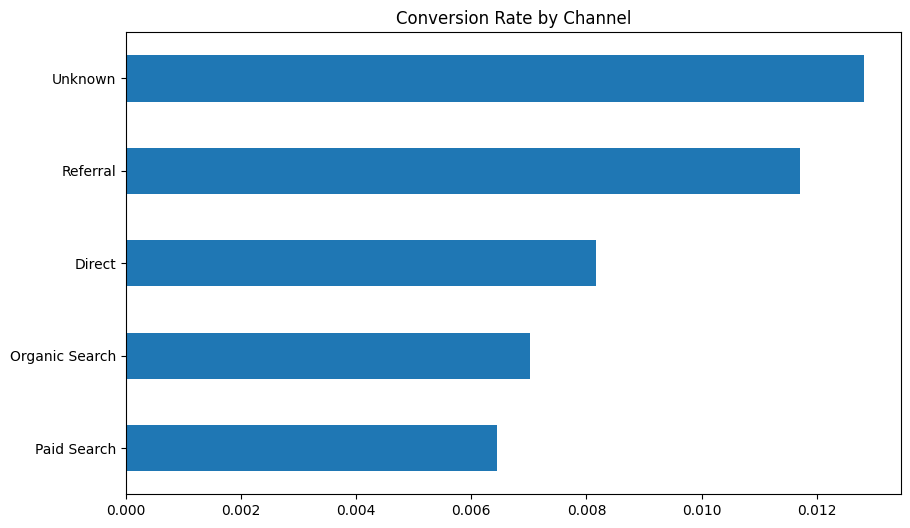

In [14]:
channel_performance["Conversion Rate"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Conversion Rate by Channel")
plt.show()

### Interpretation

Channel performance analysis shows a clear distinction between traffic volume and conversion efficiency.

Organic Search generates the highest number of sessions, indicating strong performance in driving awareness and acquisition. However, its conversion rate is lower than other channels, suggesting that many users are in the early stages of the decision-making process.

Referral traffic exhibits a higher conversion rate, indicating that users arriving through referral sources are likely further along in the funnel and have higher intent.

Direct traffic shows moderate conversion efficiency, which aligns with earlier findings that users often return directly to complete purchases.

Paid Search shows relatively low conversion rates in this dataset. However, this is likely due to limited representation in the sample dataset rather than an indication of poor performance.

Additionally, a significant portion of traffic is categorized as "Unknown," reflecting limitations in tracking and data anonymization within the GA4 dataset.

Overall, these findings reinforce the importance of analyzing both traffic volume and conversion efficiency to fully understand channel performance.

## Executive Summary

This analysis reconstructed customer journeys from GA4 event-level data and evaluated marketing channel performance using multiple attribution models.

The results demonstrate that customer conversions are influenced by multiple touchpoints rather than a single interaction.

Key takeaways:

• Organic Search plays a critical role in customer acquisition and early-stage engagement  
• Referral channels contribute significantly to mid-funnel consideration  
• Direct traffic primarily captures returning users completing conversions  
• Last-click attribution overemphasizes final touchpoints and underestimates acquisition channels  

These findings highlight the importance of adopting multi-touch attribution models to better understand marketing effectiveness and optimize channel investment strategies.